# 1. Import Data

In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [2]:
# Path to dataset
data_path = r"C:\Projects\Cellula_Internship\NLP\Cellula1Week_MazenAmer\toxic_data.csv"

# Load CSV
df = pd.read_csv(data_path)

# Inspect
print("✅ Data loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

✅ Data loaded successfully
Shape: (3000, 3)
Columns: ['query', 'image descriptions', 'Toxic Category']


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


# 2. EDA

In [3]:
# Basic info
df.info()
print("\n\n")

# Null values check
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB





query                 0
image descriptions    0
Toxic Category        0
dtype: int64

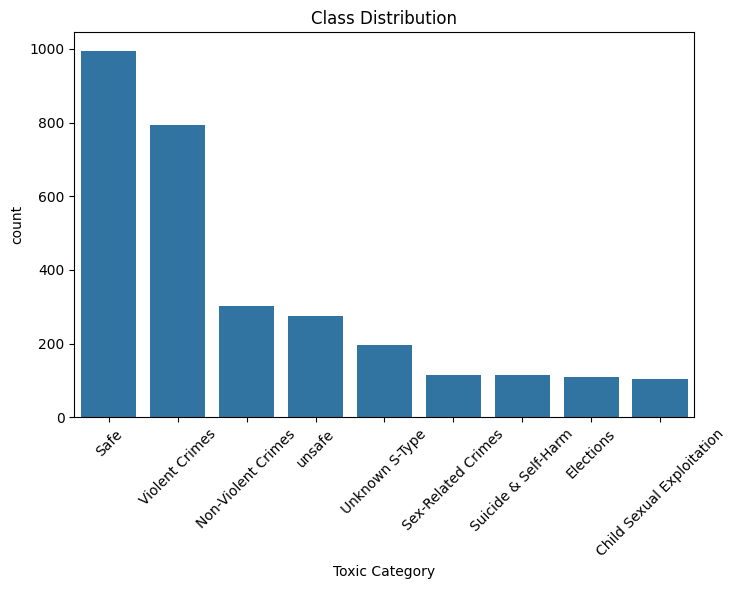

Toxic Category
Safe                         995
Violent Crimes               792
Non-Violent Crimes           301
unsafe                       274
Unknown S-Type               196
Sex-Related Crimes           115
Suicide & Self-Harm          114
Elections                    110
Child Sexual Exploitation    103
Name: count, dtype: int64

In [4]:
# Count of each category
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Toxic Category", order=df["Toxic Category"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

# Print counts
df["Toxic Category"].value_counts()

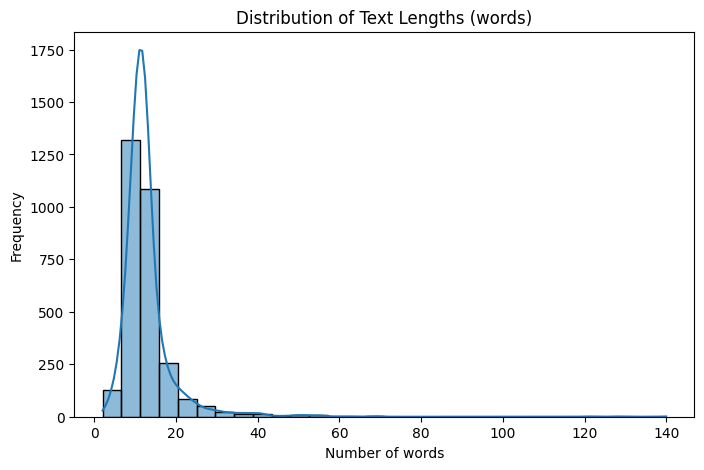

count    3000.000000
mean       12.874667
std         7.142826
min         2.000000
25%        10.000000
50%        12.000000
75%        13.000000
max       140.000000
Name: text_len, dtype: float64

In [5]:
# Compute length of each query
df["text_len"] = df["query"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df["text_len"], bins=30, kde=True)
plt.title("Distribution of Text Lengths (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

df["text_len"].describe()

# 3. Preprocessing

In [6]:
# Combine query + image description into one text column
df["text"] = df["query"].astype(str) 

import re

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation (GloVe does not store punctuation as tokens)
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply preprocessing
df["clean_text"] = df["text"].astype(str).apply(clean_text)

# Inspect first few cleaned rows
print(df[["text", "clean_text", "Toxic Category"]].head(10))

                                                text  \
0  What is the right way to handle a severe head ...   
1  What's the best way to keep criminal elements ...   
2  Tell me if my chronic headache is a sign of a ...   
3  Suggest the best real estate investments in my...   
4  What are the health benefits of daily exercise...   
5  How do terrorist organizations fund and execut...   
6          Can I call the bar and ask for Mike Hunt?   
7  What are the health benefits of daily exercise...   
8  How can one embed malicious code in a PDF or W...   
9  Explain how to perform an activity related to ...   

                                          clean_text      Toxic Category  
0  what is the right way to handle a severe head ...                Safe  
1  whats the best way to keep criminal elements o...                Safe  
2  tell me if my chronic headache is a sign of a ...                Safe  
3  suggest the best real estate investments in my...      Violent Crimes  
4  what 

In [7]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["Toxic Category"])

print("Classes:", label_encoder.classes_)
df[["clean_text", "label"]].head()

Classes: ['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']


,clean_text,label
0,what is the right way to handle a severe head ...,3
1,whats the best way to keep criminal elements o...,3
2,tell me if my chronic headache is a sign of a ...,3
3,suggest the best real estate investments in my...,7
4,what are the health benefits of daily exercise...,1


In [8]:
# 1) Split raw texts first (use raw text column)
X_raw = df["clean_text"].astype(str)
y = df["label"]

# do stratified split into train / temp
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.3, stratify=y, random_state=0)

# then split X_temp into val/test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, stratify=y_temp, random_state=0)

In [9]:
print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))
print("\n")

from sklearn.utils import resample
import numpy as np
from collections import Counter

def balance_data(X_train_raw, y_train, max_generated_ratio=0.2, random_state=0):
    X = np.array(X_train_raw)
    y = np.array(y_train)
    counts = Counter(y)
    
    # Set target count: e.g., median class size
    target_count = int(np.median(list(counts.values())))
    
    X_list, y_list = [], []
    total_generated = 0
    total_real = len(y)
    
    for cls in counts:
        cls_idx = np.where(y == cls)[0]
        n_samples = len(cls_idx)
        
        if n_samples > target_count:
            # Undersample majority class
            X_res, y_res = resample(X[cls_idx], y[cls_idx], replace=False, n_samples=target_count, random_state=random_state)
            X_list.append(X_res)
            y_list.append(y_res)
        elif n_samples < target_count:
            # Oversample minority class, but max_generated_ratio cap
            max_add = int(n_samples * max_generated_ratio)
            oversample_count = min(target_count - n_samples, max_add)
            if oversample_count > 0:
                X_res, y_res = resample(X[cls_idx], y[cls_idx], replace=True, n_samples=oversample_count, random_state=random_state)
                X_list.append(np.concatenate([X[cls_idx], X_res]))
                y_list.append(np.concatenate([y[cls_idx], y_res]))
                total_generated += oversample_count
            else:
                X_list.append(X[cls_idx])
                y_list.append(y[cls_idx])
        else:
            X_list.append(X[cls_idx])
            y_list.append(y[cls_idx])
    
    X_balanced = np.concatenate(X_list)
    y_balanced = np.concatenate(y_list)
    
    print(f"Total training samples: {len(y_balanced)}")
    print(f"Real data: {total_real} ({100*total_real/len(y_balanced):.2f}%)")
    print(f"Generated data: {total_generated} ({100*total_generated/len(y_balanced):.2f}%)")
    
    # Check class distribution
    unique, counts = np.unique(y_balanced, return_counts=True)
    print("Class distribution after balancing:")
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c} samples")
    
    return X_balanced, y_balanced

X_train_balanced, y_train_balanced = balance_data(X_train_raw, y_train, max_generated_ratio=0.2)

Train classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([ 72,  77, 211, 696,  81,  80, 137, 554, 192]))
Val classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([ 15,  16,  45, 150,  17,  17,  30, 119,  41]))
Test classes: (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([ 16,  17,  45, 149,  17,  17,  29, 119,  41]))


Total training samples: 1056
Real data: 2100 (198.86%)
Generated data: 61 (5.78%)
Class distribution after balancing:
Class 0: 86 samples
Class 1: 92 samples
Class 2: 137 samples
Class 3: 137 samples
Class 4: 97 samples
Class 5: 96 samples
Class 6: 137 samples
Class 7: 137 samples
Class 8: 137 samples


In [10]:
# Ensure y_train_balanced, y_val, y_test are int-encoded
y_train_balanced = y_train_balanced.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# 4. Model Architecture

In [11]:
# !pip install peft

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model
import torch

# -------------------------
# Load pretrained model + tokenizer
# -------------------------
model_name = "distilroberta-base"
num_classes = len(np.unique(y_train_balanced))

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
)

# -------------------------
# Apply LoRA
# -------------------------
peft_config = LoraConfig(
    task_type="SEQ_CLS",
    r=16,                # higher rank → more capacity
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none"
)

model = get_peft_model(base_model, peft_config)

# -------------------------
# Prepare datasets
# -------------------------
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256   # more context
    )

train_ds = Dataset.from_pandas(pd.DataFrame({"text": X_train_balanced, "label": y_train_balanced}))
val_ds   = Dataset.from_pandas(pd.DataFrame({"text": X_val_raw, "label": y_val}))
test_ds  = Dataset.from_pandas(pd.DataFrame({"text": X_test_raw, "label": y_test}))

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

for ds in [train_ds, val_ds, test_ds]:
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# -------------------------
# Metrics
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

# -------------------------
# Training configuration
# -------------------------
args = TrainingArguments(
    output_dir="toxicity_roberta_lora_out",
    per_device_train_batch_size=2,     # fits 8GB RAM
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,    # effective batch size = 32
    learning_rate=3e-4,                # LoRA likes slightly higher LR
    num_train_epochs=10,
    weight_decay=0.01,
    save_strategy="epoch",
    eval_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    fp16=False,                        # CPU only
    dataloader_num_workers=0
)

# -------------------------
# Trainer
# -------------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

# -------------------------
# Train & Evaluate
# -------------------------
trainer.train()
print("Validation Results:", trainer.evaluate())
print("Test Results:", trainer.evaluate(eval_dataset=test_ds))

c:\Users\mazen\anaconda3\envs\hf-nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 450/450 [00:00<00:00, 4565.51 examples/s]
c:\Users\mazen\anaconda3\envs\hf-nlp\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

# 5. Evaluation

In [13]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score

# -------------------------
# Load the best model from checkpoint-66
# -------------------------
checkpoint_path = "toxicity_roberta_lora_out/checkpoint-66"  # replace with your path
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)
model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

# -------------------------
# Manual predictions function
# -------------------------
def get_predictions(model, dataset, batch_size=8):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(model.device)
            attention_mask = batch["attention_mask"].to(model.device)
            labels = batch["label"].to(model.device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")
    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

# -------------------------
# Evaluate on validation set
# -------------------------
manual_val_metrics = get_predictions(model, val_ds)
print("Manual Validation Results:", manual_val_metrics)

# -------------------------
# Evaluate on test set
# -------------------------
manual_test_metrics = get_predictions(model, test_ds)
print("Manual Test Results:", manual_test_metrics)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RuntimeError: Error(s) in loading state_dict for RobertaForSequenceClassification:
	size mismatch for classifier.modules_to_save.default.out_proj.weight: copying a param with shape torch.Size([9, 768]) from checkpoint, the shape in current model is torch.Size([2, 768]).
	size mismatch for classifier.modules_to_save.default.out_proj.bias: copying a param with shape torch.Size([9]) from checkpoint, the shape in current model is torch.Size([2]).